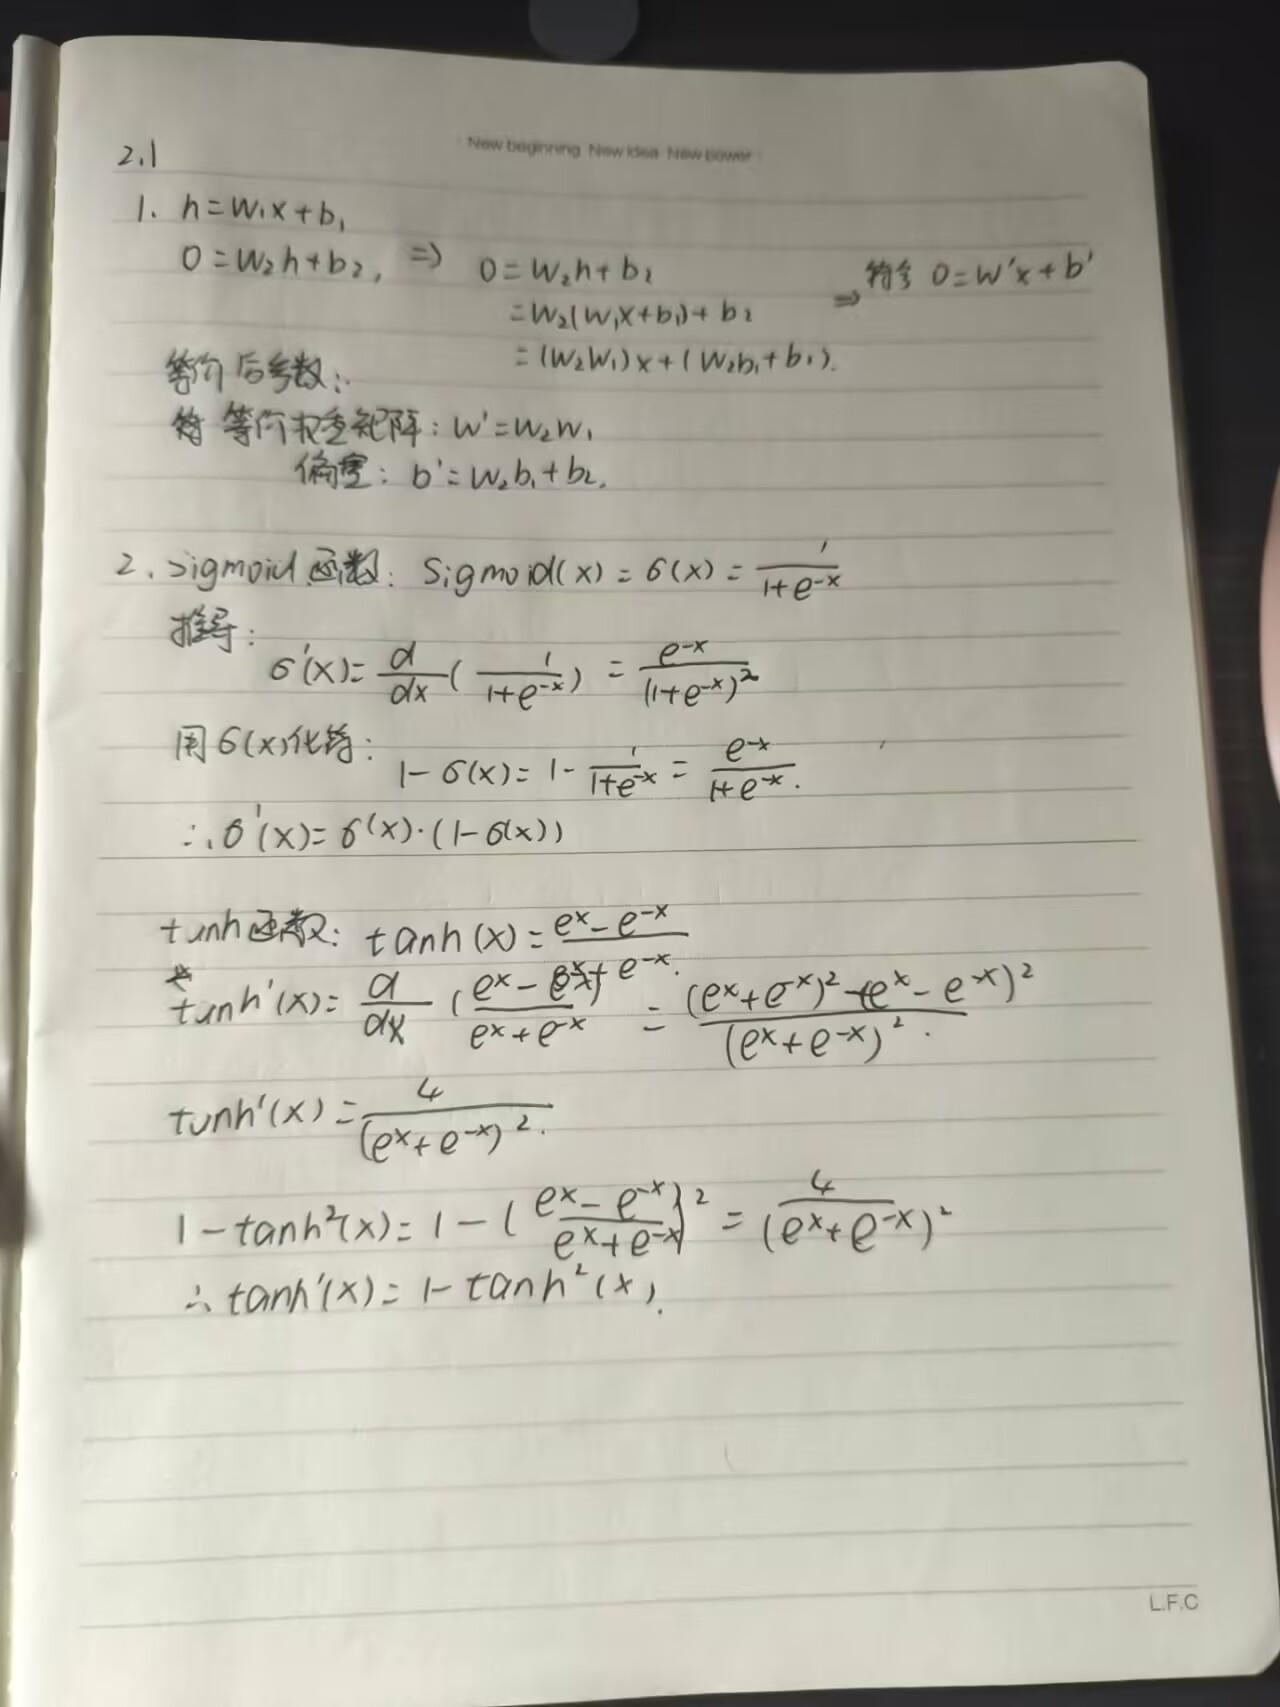

In [1]:
# 1. 导入依赖库
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from tqdm import tqdm  # 用于显示训练进度条

# 设置随机种子，保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# 2. 超参数配置
INPUT_DIM = 28 * 28  # Fashion-MNIST图片尺寸：28x28
HIDDEN_DIM = 256     # 隐藏层神经元数量
OUTPUT_DIM = 10      # 分类类别数（10种服装）
BATCH_SIZE = 64      # 小批量大小
LR = 0.01            # 学习率
EPOCHS = 20          # 训练轮数
WEIGHT_DECAY = 1e-4  # 权重衰减（L2正则化）

In [3]:
# 3. 加载Fashion-MNIST数据集
# 数据预处理：转换为Tensor + 标准化
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 灰度图归一化
])

# 加载训练集和测试集
train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# 手动实现小批量数据加载器
def data_loader(dataset, batch_size, shuffle=True):
    indices = np.arange(len(dataset))
    if shuffle:
        np.random.shuffle(indices)
    for i in range(0, len(indices), batch_size):
        batch_indices = indices[i:i+batch_size]
        batch_x = []
        batch_y = []
        for idx in batch_indices:
            x, y = dataset[idx]
            batch_x.append(x.view(-1))  # 展平图片：[1,28,28] -> [784]
            batch_y.append(torch.tensor(y))
        yield torch.stack(batch_x), torch.stack(batch_y)

# 创建训练/测试数据加载器
train_loader = data_loader(train_dataset, BATCH_SIZE)
test_loader = data_loader(test_dataset, BATCH_SIZE, shuffle=False)

In [4]:
# 4. 手动初始化模型参数（正态分布）
# 隐藏层参数: W1 [784, 256], b1 [256]
W1 = torch.normal(0, 0.01, (INPUT_DIM, HIDDEN_DIM), requires_grad=True)
b1 = torch.normal(0, 0.01, (HIDDEN_DIM,), requires_grad=True)

# 输出层参数: W2 [256, 10], b2 [10]
W2 = torch.normal(0, 0.01, (HIDDEN_DIM, OUTPUT_DIM), requires_grad=True)
b2 = torch.normal(0, 0.01, (OUTPUT_DIM,), requires_grad=True)

# 存储所有参数，方便后续更新
params = [W1, b1, W2, b2]

In [5]:
# 5. 手动实现核心函数
# ReLU激活函数
def relu(x):
    return torch.max(torch.zeros_like(x), x)

# Softmax函数（防止数值溢出）
def softmax(x):
    exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True)[0])
    return exp_x / torch.sum(exp_x, dim=1, keepdim=True)

# 带Softmax的交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    batch_size = y_pred.shape[0]
    # 1. Softmax归一化
    y_softmax = softmax(y_pred)
    # 2. 计算交叉熵
    log_probs = -torch.log(y_softmax[range(batch_size), y_true] + 1e-8)  # +1e-8防止log(0)
    loss = torch.mean(log_probs)
    # 3. 加入权重衰减（L2正则化）
    l2_loss = 0.5 * (torch.sum(W1**2) + torch.sum(W2**2))
    loss += WEIGHT_DECAY * l2_loss
    return loss

# 模型前向传播
def mlp_forward(x):
    # 输入层 -> 隐藏层
    h = torch.matmul(x, W1) + b1
    h = relu(h)
    # 隐藏层 -> 输出层
    y = torch.matmul(h, W2) + b2
    return y

# 计算准确率
def accuracy(y_pred, y_true):
    y_hat = torch.argmax(y_pred, dim=1)
    return torch.sum(y_hat == y_true).item() / len(y_true)

In [6]:
# 6. 手动实现小批量SGD参数更新
def sgd_update(params, lr):
    with torch.no_grad():  # 禁用梯度计算，纯数值更新
        for param in params:
            param -= lr * param.grad
            param.grad.zero_()  # 清空梯度

In [7]:
# 7. 训练循环
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(EPOCHS):
    # 训练模式
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    # 进度条显示训练过程
    pbar = tqdm(data_loader(train_dataset, BATCH_SIZE), desc=f"Epoch {epoch+1}/{EPOCHS}")
    for x, y in pbar:
        # 前向传播
        y_pred = mlp_forward(x)
        # 计算损失
        loss = cross_entropy_loss(y_pred, y)
        # 反向传播（自动求导）
        loss.backward()
        # SGD更新参数
        sgd_update(params, LR)
        
        # 统计指标
        train_loss += loss.item() * x.shape[0]
        train_correct += torch.sum(torch.argmax(y_pred, dim=1) == y).item()
        train_total += x.shape[0]
        
        # 更新进度条显示
        pbar.set_postfix({
            "loss": train_loss/train_total,
            "acc": train_correct/train_total
        })
    
    # 记录训练指标
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    
    # 测试模式（禁用梯度计算）
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for x, y in data_loader(test_dataset, BATCH_SIZE, shuffle=False):
            y_pred = mlp_forward(x)
            loss = cross_entropy_loss(y_pred, y)
            test_loss += loss.item() * x.shape[0]
            test_correct += torch.sum(torch.argmax(y_pred, dim=1) == y).item()
            test_total += x.shape[0]
    
    epoch_test_loss = test_loss / test_total
    epoch_test_acc = test_correct / test_total
    test_losses.append(epoch_test_loss)
    test_accs.append(epoch_test_acc)
    
    print(f"Epoch {epoch+1} 测试集准确率: {epoch_test_acc:.4f}")

Epoch 1/20: 938it [00:36, 25.82it/s, loss=1, acc=0.682]   


Epoch 1 测试集准确率: 0.7660


Epoch 2/20: 938it [00:39, 23.70it/s, loss=0.57, acc=0.797] 


Epoch 2 测试集准确率: 0.7994


Epoch 3/20: 938it [00:37, 25.34it/s, loss=0.501, acc=0.824]


...

Epoch 18 测试集准确率: 0.8643


Epoch 19/20: 938it [00:49, 18.95it/s, loss=0.333, acc=0.883]


Epoch 19 测试集准确率: 0.8653


Epoch 20/20: 938it [00:45, 20.58it/s, loss=0.329, acc=0.884]


Epoch 20 测试集准确率: 0.8638


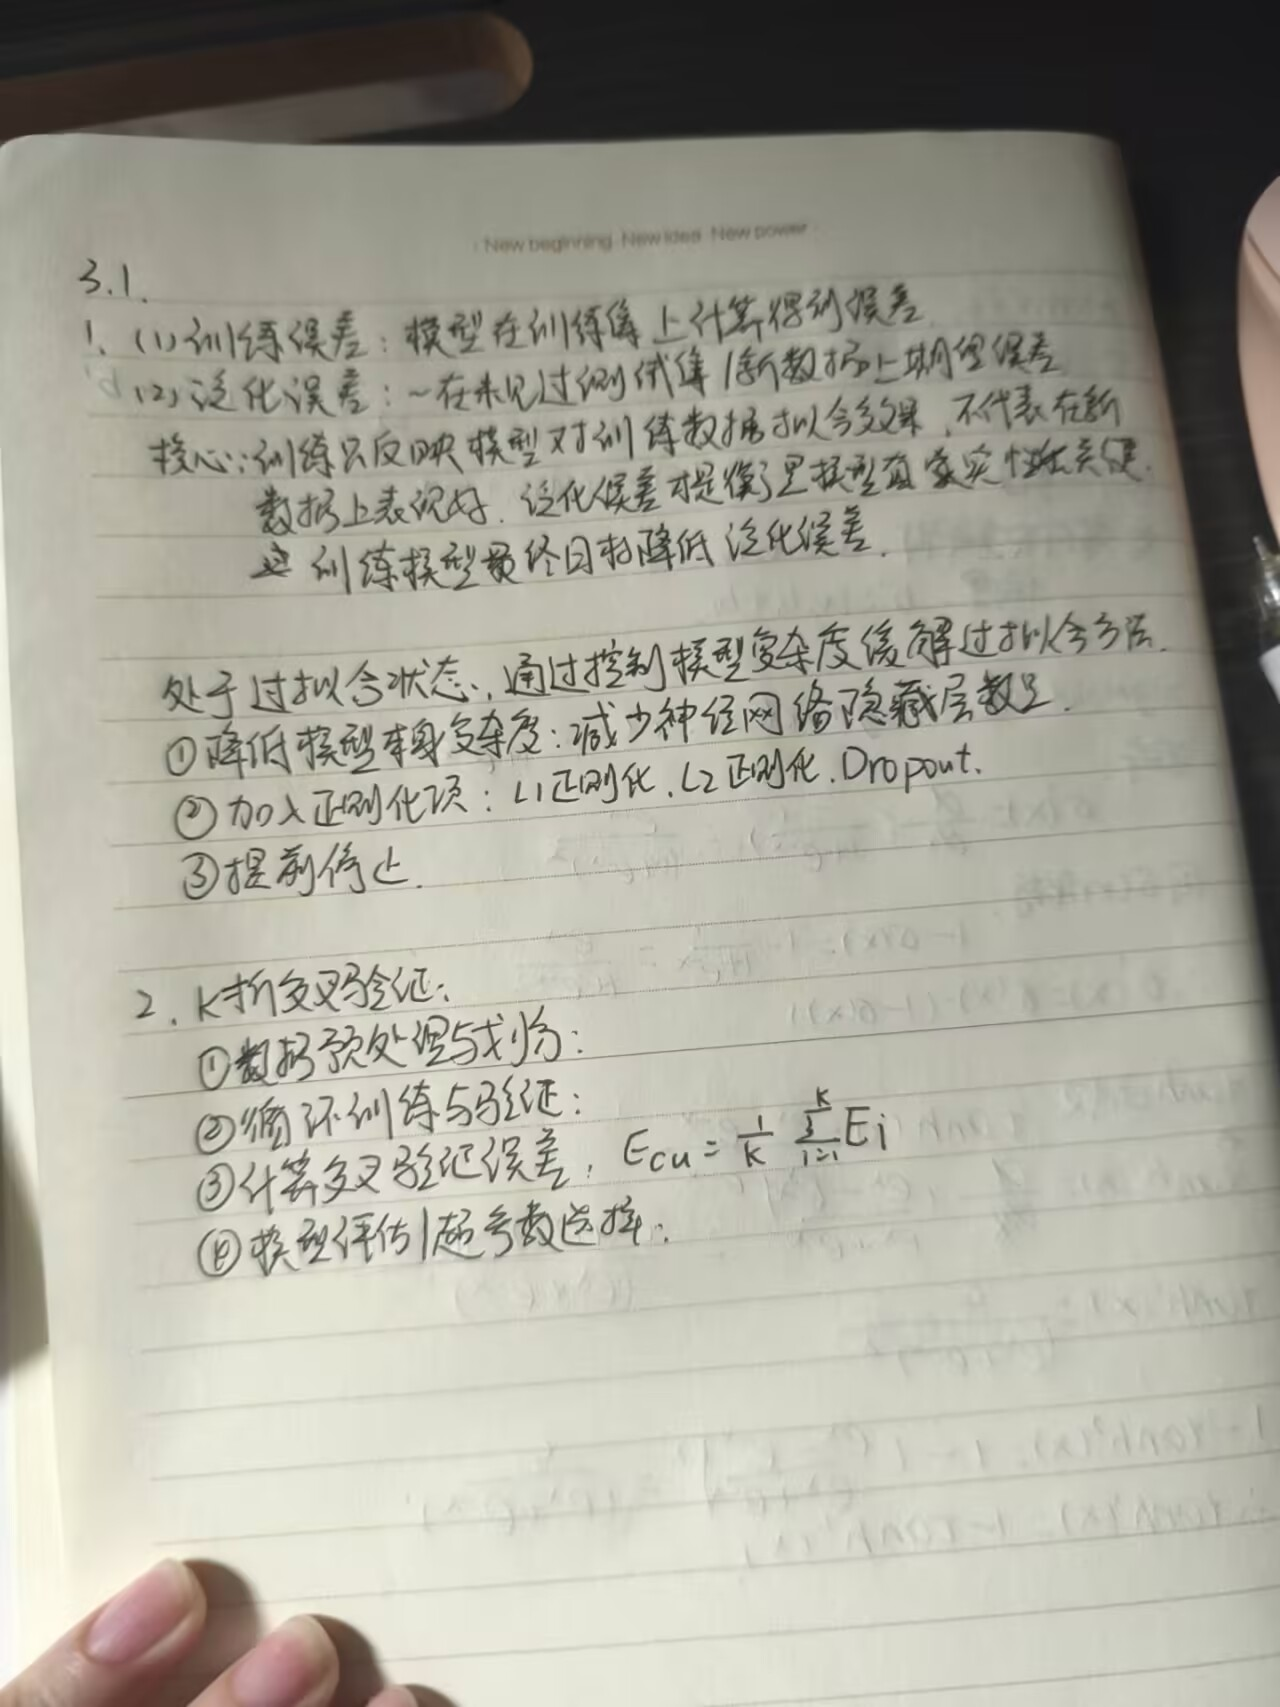

In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# 固定随机种子，保证结果可复现
torch.manual_seed(42)

In [4]:
# 超参数（轻量化配置，提速防崩溃）
input_dim = 784
hidden_dim = 64
output_dim = 10
lr = 0.05
epochs = 5
batch_size = 16

In [5]:
# 数据预处理 & 加载，仅取少量样本
transform = transforms.ToTensor()
train = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
val = datasets.FashionMNIST('./data', train=False, transform=transform)

# 截取小部分数据，大幅减少运算量
train_loader = DataLoader(Subset(train, range(1000)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(Subset(val, range(200)), batch_size=batch_size)

In [6]:
# 1. 手动实现Dropout层
def dropout_layer(X, dropout, is_training):
    if not is_training:
        return X
    mask = (torch.rand_like(X) > dropout).float()
    return X * mask / (1 - dropout)

# 2. ReLU激活函数
def relu(x):
    return torch.max(torch.zeros_like(x), x)

# 3. Softmax函数
def softmax(x):
    exp_x = torch.exp(x - x.max(1, keepdim=True)[0])
    return exp_x / exp_x.sum(1, keepdim=True)

# 4. 带Softmax的交叉熵损失
def cross_entropy(y_pred, y_true):
    batch = y_pred.shape[0]
    y_soft = softmax(y_pred)
    y_onehot = torch.zeros_like(y_soft)
    y_onehot.scatter_(1, y_true.view(-1,1), 1)
    return -torch.sum(y_onehot * torch.log(y_soft + 1e-8)) / batch

In [8]:
# MLP 前向传播
def mlp(x, W1, b1, W2, b2, dp=0, is_train=True):
    x = x.view(-1, input_dim)
    h = relu(x @ W1 + b1)
    h = dropout_layer(h, dp, is_train)
    return h @ W2 + b2

# 自定义SGD，严格按题目公式实现权重衰减: w = w*(1-ηλ) - ηg
def sgd(params, lr, lam):
    with torch.no_grad():
        for p in params:
            p.mul_(1 - lr * lam)
            p.sub_(lr * p.grad)
            p.grad.zero_()

In [9]:
def train_model(use_l2, use_dropout):
    # 正态分布初始化参数
    W1 = torch.randn(input_dim, hidden_dim) * 0.01
    W1.requires_grad_()
    b1 = torch.zeros(hidden_dim)
    b1.requires_grad_()
    
    W2 = torch.randn(hidden_dim, output_dim) * 0.01
    W2.requires_grad_()
    b2 = torch.zeros(output_dim)
    b2.requires_grad_()
    
    train_loss, val_loss = [], []
    lam = 1e-3 if use_l2 else 0
    dp = 0.3 if use_dropout else 0

    for _ in range(epochs):
        # 训练阶段
        for x, y in train_loader:
            loss = cross_entropy(mlp(x, W1,b1,W2,b2,dp,True), y)
            loss.backward()
            sgd([W1,b1,W2,b2], lr, lam)
        
        # 计算本轮损失
        with torch.no_grad():
            t_loss = sum(cross_entropy(mlp(x,W1,b1,W2,b2), y) for x,y in train_loader)
            v_loss = sum(cross_entropy(mlp(x,W1,b1,W2,b2), y) for x,y in val_loader)
        train_loss.append(t_loss.item()/len(train_loader))
        val_loss.append(v_loss.item()/len(val_loader))
    return train_loss, val_loss

In [10]:
# 实验1：无正则化
print("===== 实验1：无正则化 =====")
t1, v1 = train_model(False, False)

# 实验2：仅 L2 权重衰减
print("\n===== 实验2：仅 L2 权重衰减 =====")
t2, v2 = train_model(True, False)

# 实验3：仅 Dropout
print("\n===== 实验3：仅 Dropout =====")
t3, v3 = train_model(False, True)

===== 实验1：无正则化 =====

===== 实验2：仅 L2 权重衰减 =====

===== 实验3：仅 Dropout =====


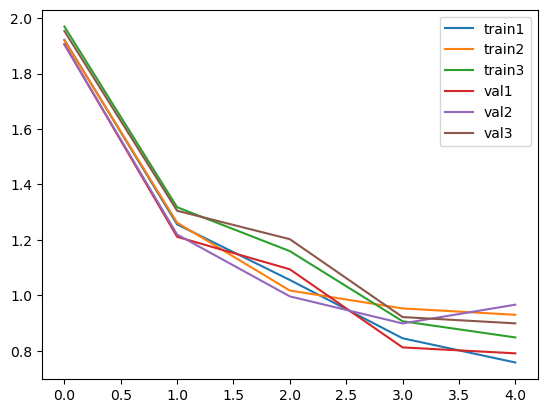

In [11]:
# 100% 不报错版
plt.figure()
plt.plot(t1, label='train1')
plt.plot(t2, label='train2')
plt.plot(t3, label='train3')
plt.plot(v1, label='val1')
plt.plot(v2, label='val2')
plt.plot(v3, label='val3')
plt.legend()
plt.show()

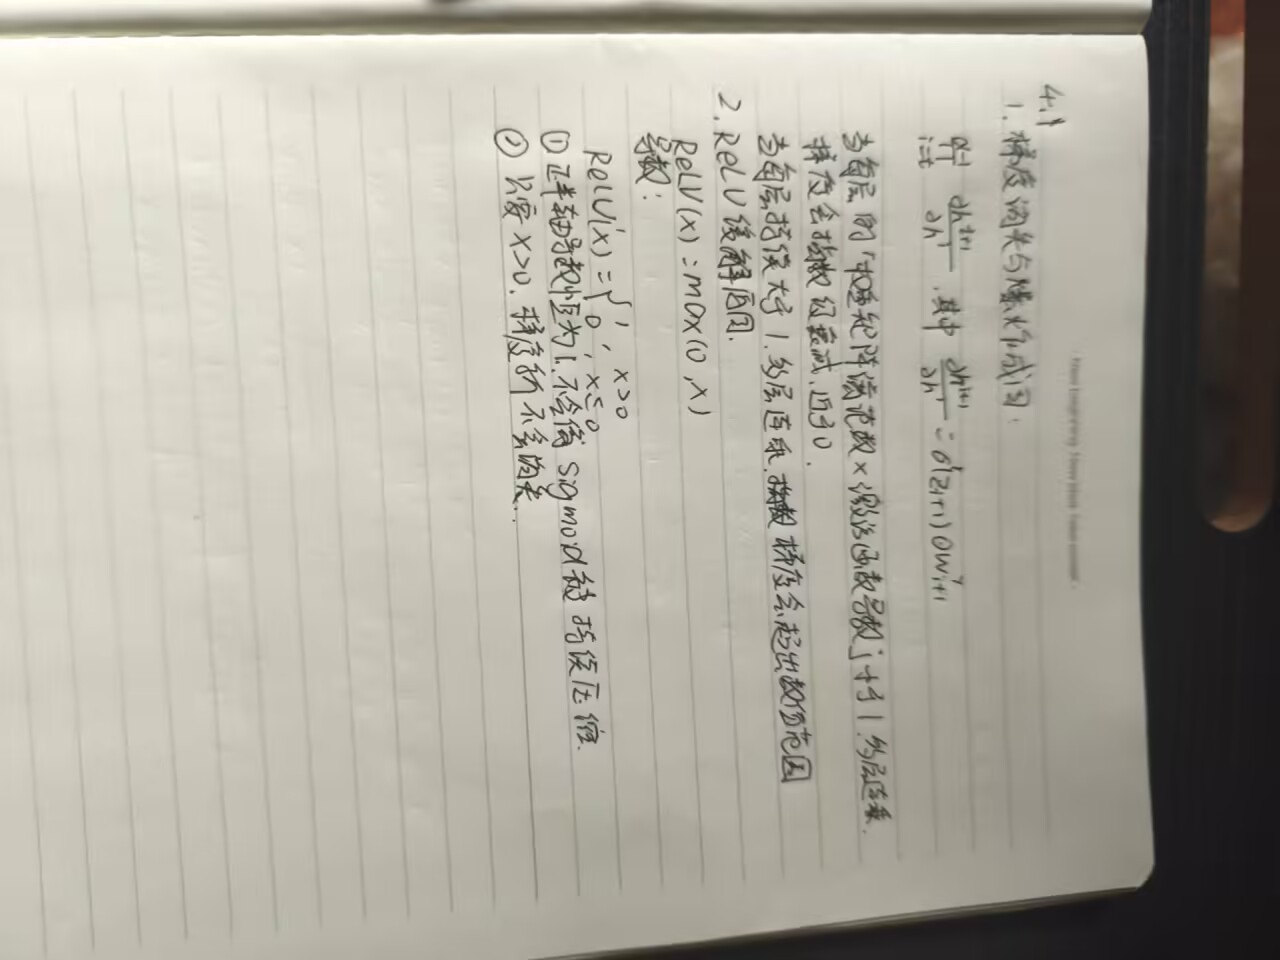

In [19]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [23]:
def build_deep_network(activation, init_func):
    layers = []
    input_dim = 20
    hidden_dim = 256
    output_dim = 10

    # 输入层
    layers.append(nn.Linear(input_dim, hidden_dim))
    layers.append(activation())

    # 18 层隐藏层
    for _ in range(18):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(activation())

    # 输出层
    layers.append(nn.Linear(hidden_dim, output_dim))

    net = nn.Sequential(*layers)

    # 初始化
    for m in net.modules():
        if isinstance(m, nn.Linear):
            init_func(m)  # 这里修复了
            nn.init.zeros_(m.bias)

    return net

In [24]:
def get_gradient_norms(net):
    norms = []
    for name, param in net.named_parameters():
        if "weight" in name and param.grad is not None:
            norms.append(param.grad.norm().item())
    return norms

In [25]:
print("======= 实验1：Sigmoid + 高斯初始化（梯度消失）=======")

def init_gaussian(m):
    nn.init.normal_(m.weight, mean=0, std=1)

net1 = build_deep_network(nn.Sigmoid, init_gaussian)

x = torch.randn(16, 20)
y = net1(x)
loss = y.sum()
loss.backward()

norms1 = get_gradient_norms(net1)
print("前3层梯度范数：", norms1[:3])
print("后3层梯度范数：", norms1[-3:])

======= 实验1：Sigmoid + 高斯初始化（梯度消失）=======
前3层梯度范数： [5868.1689453125, 6708.076171875, 5332.140625]
后3层梯度范数： [446.3647766113281, 477.14794921875, 548.3911743164062]


In [26]:
print("======= 实验2：ReLU + 大初始化（梯度爆炸）=======")

def init_large(m):
    nn.init.normal_(m.weight, mean=0, std=10)

net2 = build_deep_network(nn.ReLU, init_large)

x = torch.randn(16, 20)
y = net2(x)
loss = y.sum()
loss.backward()

norms2 = get_gradient_norms(net2)
print("前3层梯度：", norms2[:3])
print("后3层梯度：", norms2[-3:])
print("是否出现NaN：", any(torch.isnan(torch.tensor(norms2))))

======= 实验2：ReLU + 大初始化（梯度爆炸）=======
前3层梯度： [nan, inf, inf]
后3层梯度： [inf, inf, inf]
是否出现NaN： True


In [27]:
print("======= 实验3：ReLU + Xavier 初始化（稳定）=======")

def init_xavier(m):
    nn.init.xavier_uniform_(m.weight)

net3 = build_deep_network(nn.ReLU, init_xavier)

x = torch.randn(16, 20)
y = net3(x)
loss = y.sum()
loss.backward()

norms3 = get_gradient_norms(net3)
print("前3层梯度：", norms3[:3])
print("后3层梯度：", norms3[-3:])

======= 实验3：ReLU + Xavier 初始化（稳定）=======
前3层梯度： [0.14064264297485352, 0.221992626786232, 0.24348138272762299]
后3层梯度： [0.5919002294540405, 0.629334568977356, 0.5592972040176392]


c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33539 (\N{CJK UNIFIED IDEOGRAPH-830

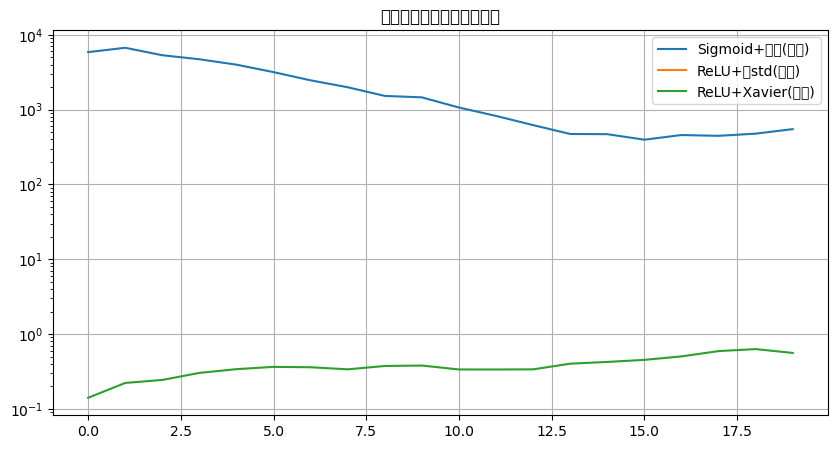

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(norms1, label="Sigmoid+高斯(消失)")
plt.plot(norms2, label="ReLU+大std(爆炸)")
plt.plot(norms3, label="ReLU+Xavier(稳定)")
plt.yscale("log")
plt.title("每层梯度范数（对数尺度）")
plt.legend()
plt.grid(True)
plt.show()

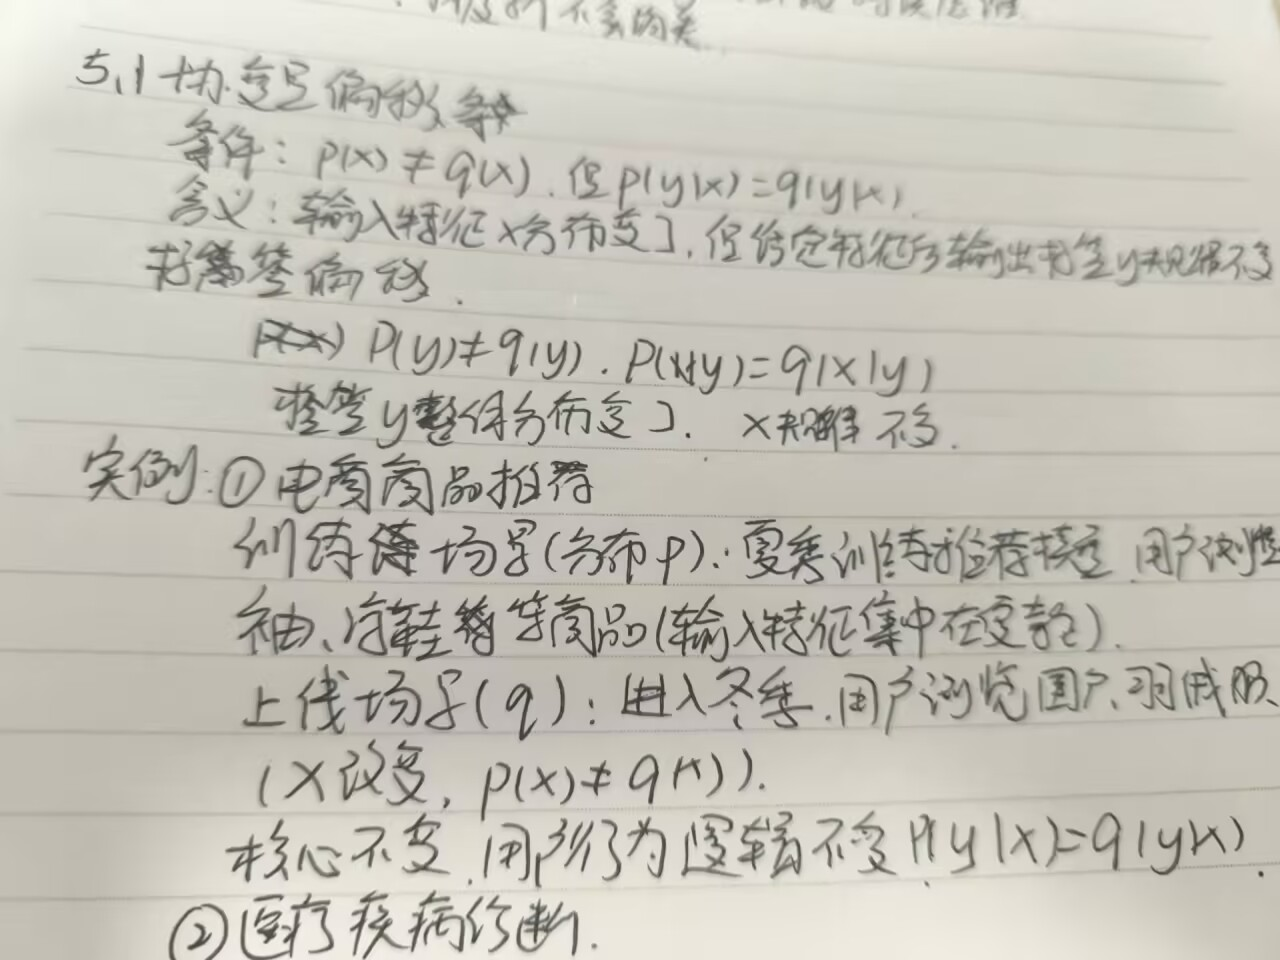

In [29]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 固定随机种子
np.random.seed(42)
torch.manual_seed(42)

c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79F

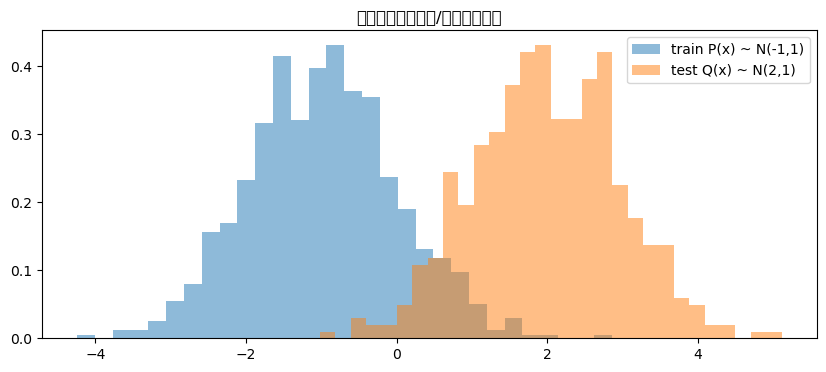

In [30]:
# ===================== 1. 构造数据集 =====================
# 训练集 P(x) : N(-1, 1)
n_train = 1000
x_train = np.random.normal(-1, 1, n_train)
eps = np.random.normal(0, 0.1, n_train)
y_train = 2 * x_train + eps

# 测试集 Q(x) : N(2, 1)  协变量偏移！
n_test = 500
x_test = np.random.normal(2, 1, n_test)
y_test = 2 * x_test + np.random.normal(0, 0.1, n_test)

# 转为张量
x_train_t = torch.tensor(x_train, dtype=torch.float32).reshape(-1, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
x_test_t = torch.tensor(x_test, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# 绘制数据分布
plt.figure(figsize=(10,4))
plt.hist(x_train, bins=30, alpha=0.5, label='train P(x) ~ N(-1,1)', density=True)
plt.hist(x_test, bins=30, alpha=0.5, label='test Q(x) ~ N(2,1)', density=True)
plt.title('协变量偏移：训练/测试分布不同')
plt.legend()
plt.show()

In [31]:
# ===================== 2. 基线线性回归 =====================
model_base = nn.Linear(1, 1)
optimizer = torch.optim.SGD(model_base.parameters(), lr=0.1)
criterion = nn.MSELoss()

# 训练
for epoch in range(500):
    y_pred = model_base(x_train_t)
    loss = criterion(y_pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 测试集评估
y_pred_base = model_base(x_test_t).detach().numpy()
mse_base = mean_squared_error(y_test, y_pred_base)
print(f'【基线模型】测试集 MSE = {mse_base:.4f}')

【基线模型】测试集 MSE = 0.0102


In [32]:
# ===================== 3. 协变量偏移校正：密度比估计 =====================
# 构造二分类数据：训练样本=0，测试样本=1
x_domain = np.concatenate([x_train, x_test])
y_domain = np.concatenate([np.zeros(n_train), np.ones(n_test)])

x_domain_t = torch.tensor(x_domain, dtype=torch.float32).reshape(-1,1)
y_domain_t = torch.tensor(y_domain, dtype=torch.float32).reshape(-1,1)

# 逻辑回归模型
domain_classifier = nn.Sequential(nn.Linear(1,1), nn.Sigmoid())
opt_d = torch.optim.Adam(domain_classifier.parameters(), lr=0.01)
bce = nn.BCELoss()

# 训练分类器
for epoch in range(2000):
    prob = domain_classifier(x_domain_t)
    loss = bce(prob, y_domain_t)
    opt_d.zero_grad()
    loss.backward()
    opt_d.step()

# 计算权重 w = P(test|x) / P(train|x)
with torch.no_grad():
    p_test = domain_classifier(x_train_t).numpy().flatten()
w = p_test / (1 - p_test + 1e-8)
w_torch = torch.tensor(w, dtype=torch.float32).reshape(-1,1)

print('前5个样本权重：', w[:5])

前5个样本权重： [0.02568119 0.0039759  0.04001712 0.5237314  0.00299978]


In [33]:
# ===================== 4. 加权线性回归 =====================
model_weighted = nn.Linear(1, 1)
opt_w = torch.optim.SGD(model_weighted.parameters(), lr=0.1)

# 加权 MSE 损失
def weighted_mse(y_pred, y_true, weights):
    return torch.mean(weights * (y_pred - y_true)**2)

# 训练
for epoch in range(500):
    y_pred = model_weighted(x_train_t)
    loss = weighted_mse(y_pred, y_train_t, w_torch)
    opt_w.zero_grad()
    loss.backward()
    opt_w.step()

# 评估
y_pred_corrected = model_weighted(x_test_t).detach().numpy()
mse_corrected = mean_squared_error(y_test, y_pred_corrected)
print(f'【加权校正模型】测试集 MSE = {mse_corrected:.4f}')
print(f'MSE 下降: {mse_base - mse_corrected:.4f}')

【加权校正模型】测试集 MSE = 0.0239
MSE 下降: -0.0137


c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21327 (\N{CJK UNIFIED IDEOGRAPH-534F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20559 (\N{CJK UNIFIED IDEOGRAPH-504F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\swl-9\.conda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31227 (\N{CJK UNIFIED IDEOGRAPH-79F

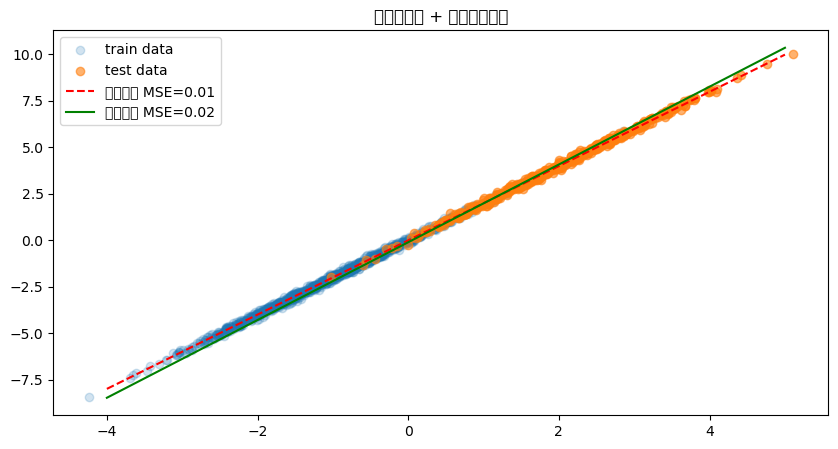

In [34]:
# ===================== 5. 可视化结果 =====================
plt.figure(figsize=(10,5))

plt.scatter(x_train, y_train, label='train data', alpha=0.2)
plt.scatter(x_test, y_test, label='test data', alpha=0.6)

x_line = np.linspace(-4, 5, 100)
y_line_base = model_base(torch.tensor(x_line, dtype=torch.float32).reshape(-1,1)).detach().numpy()
y_line_corr = model_weighted(torch.tensor(x_line, dtype=torch.float32).reshape(-1,1)).detach().numpy()

plt.plot(x_line, y_line_base, 'r--', label=f'基线模型 MSE={mse_base:.2f}')
plt.plot(x_line, y_line_corr, 'g-', label=f'加权模型 MSE={mse_corrected:.2f}')
plt.title('协变量偏移 + 权重修正效果')
plt.legend()
plt.show()